# Cutomer Churn Classification
### Bank mijozlarining roziligini aniqlash

In [18]:
# working with data
import pandas as pd
import numpy as np

# working with graphs
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# for src files
from data.load import load_data

- mijoz identifikatori (RowNumber, CustomerId, Surname);
- geografik joylashuvi (Geography);
- jinsi (Gender);
- yoshi (Age);
- kredit balli (CreditScore);
- yillik daromadi (EstimatedSalary);
- bankda qancha vaqtdan beri mijoz ekani (Tenure);
- qancha mahsulotdan foydalanishi (NumOfProducts);
- faoliyati (HasCrCard, IsActiveMember);
- balans (Balance);
- prognoz qilish holati, churn (Exited) – maqsadli oʻzgaruvchi.

In [19]:
# loading data
df = load_data("Churn_Modelling.xls")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [20]:
# Checking shape
df.shape

(10000, 14)

In [21]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [22]:
# Basic statistics
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [23]:
df.describe(include=["object"]).T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [24]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [25]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

## EDA

In [26]:
def countplot(col):
    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    sns.countplot(data=df, x=col)
    plt.title(f"Distrbution of {col}")
    plt.grid()

    plt.subplot(1,2,2)
    sns.countplot(data=df, x = col, hue="Exited")
    plt.title(f"Distrbution of {col} by Exited")
    plt.grid()

    plt.show()

In [27]:
# Countplot uchun ustunlarni ajratib olamiz
countplot_col = ["Geography", "Gender", "Tenure", "NumOfProducts", "HasCrCard", "IsActiveMember"]

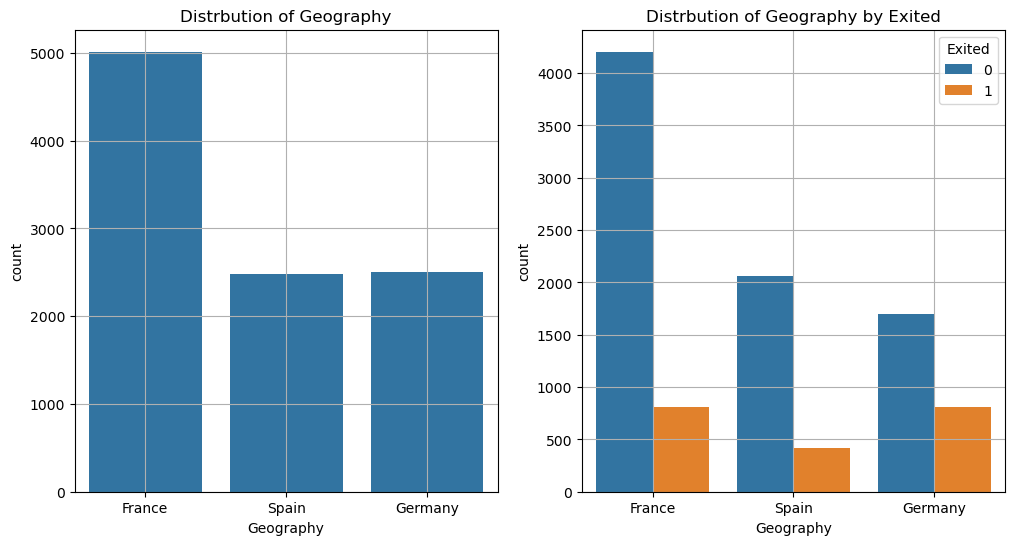

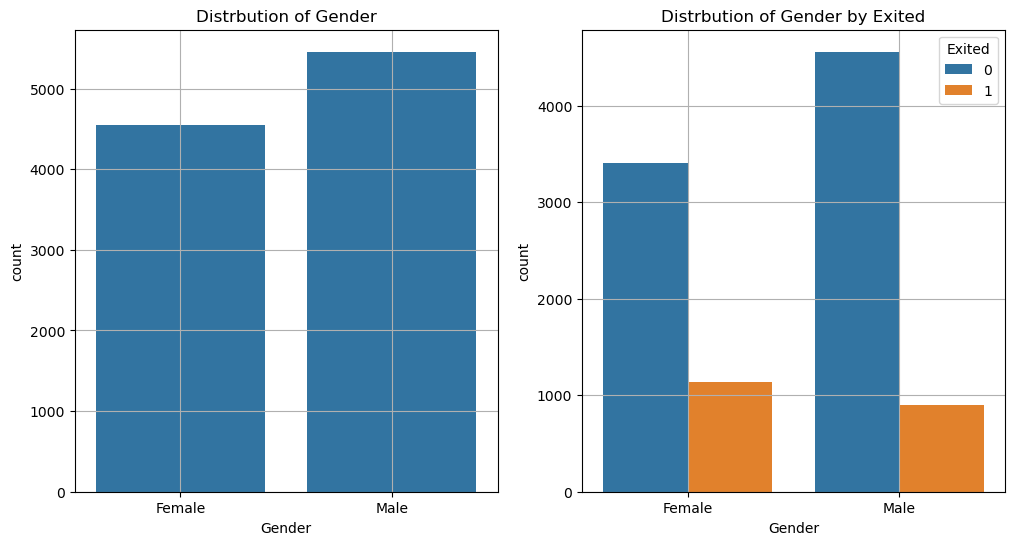

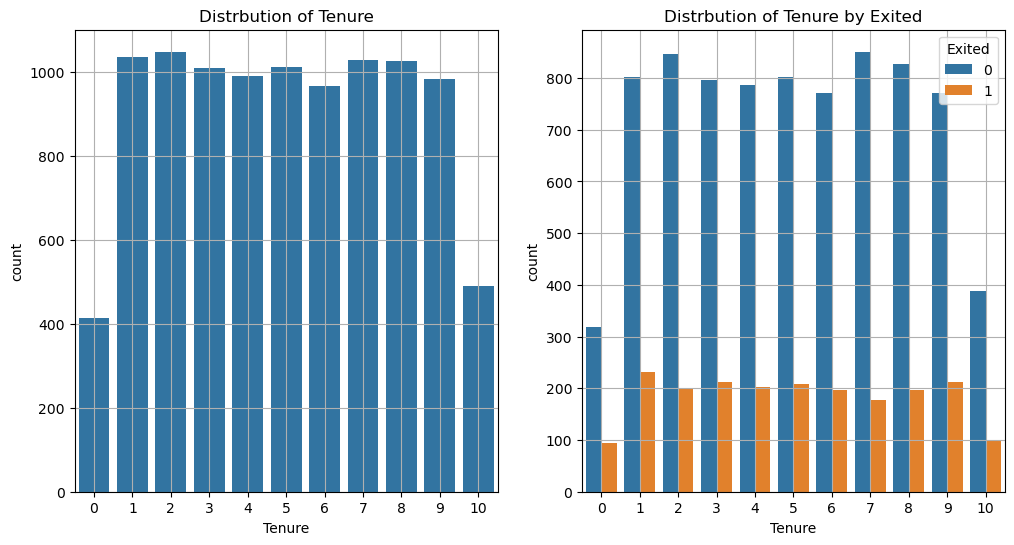

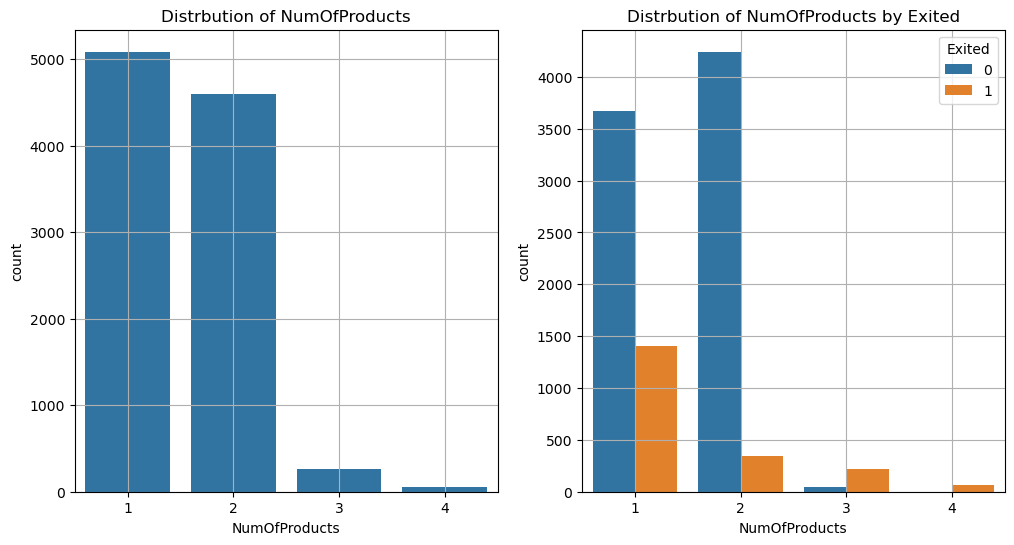

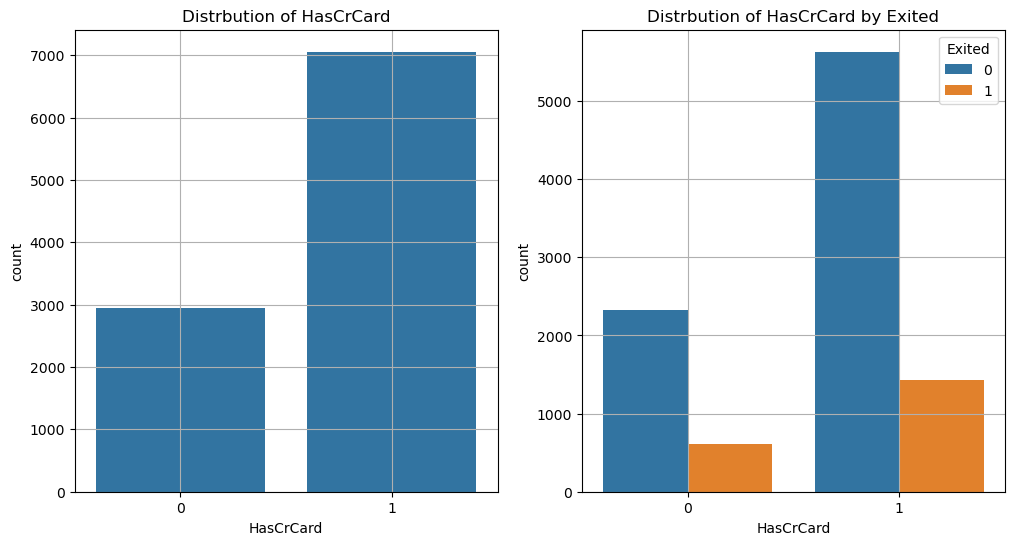

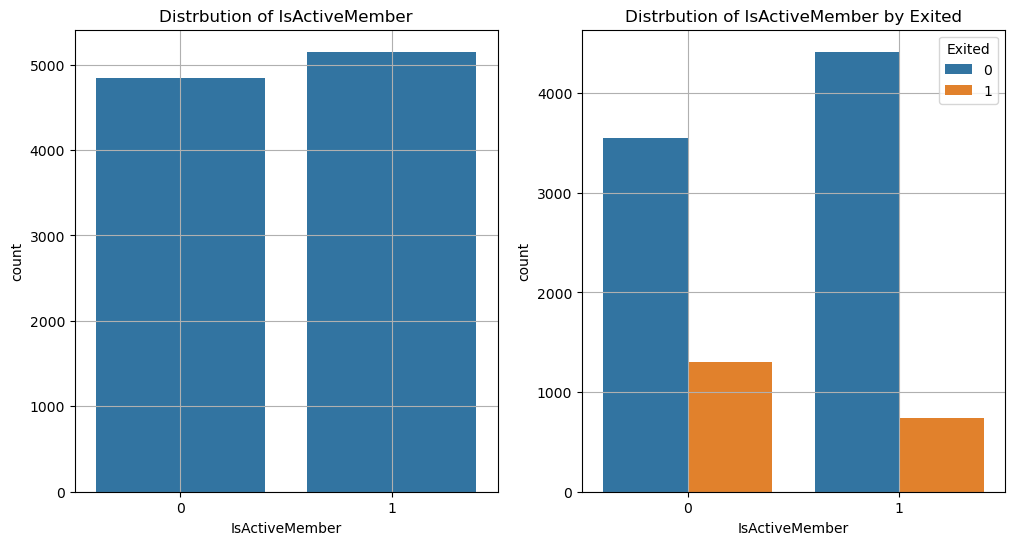

In [28]:
for col in countplot_col:
    countplot(col)

In [29]:
histplot_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

In [30]:
def histplot(col):
    plt.figure(figsize=(18,6))

    plt.subplot(1,2,1)
    sns.histplot(data=df, x=col, hue="Exited")
    plt.title(f"Distribution of {col} by Exited")
    plt.grid()

    plt.subplot(1,2,2)
    sns.boxplot(data=df, x = "Exited", y=col, hue="Exited")
    plt.title(f"Boxplot of {col} by Exited")
    plt.grid()
    
    plt.show()

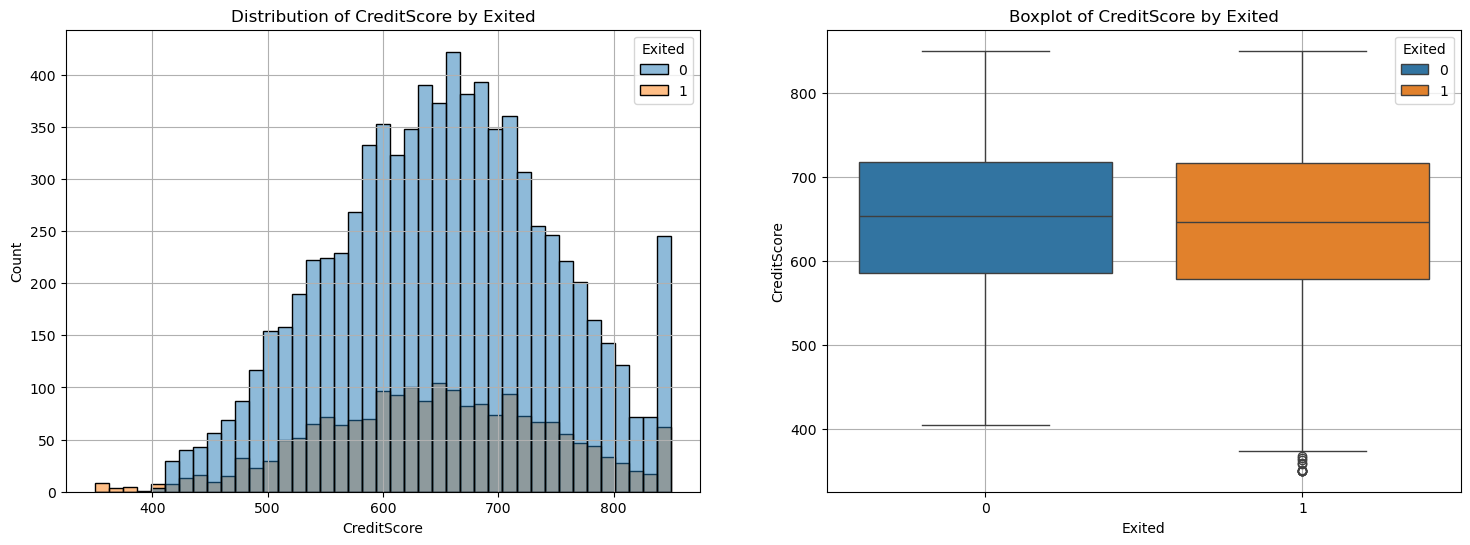

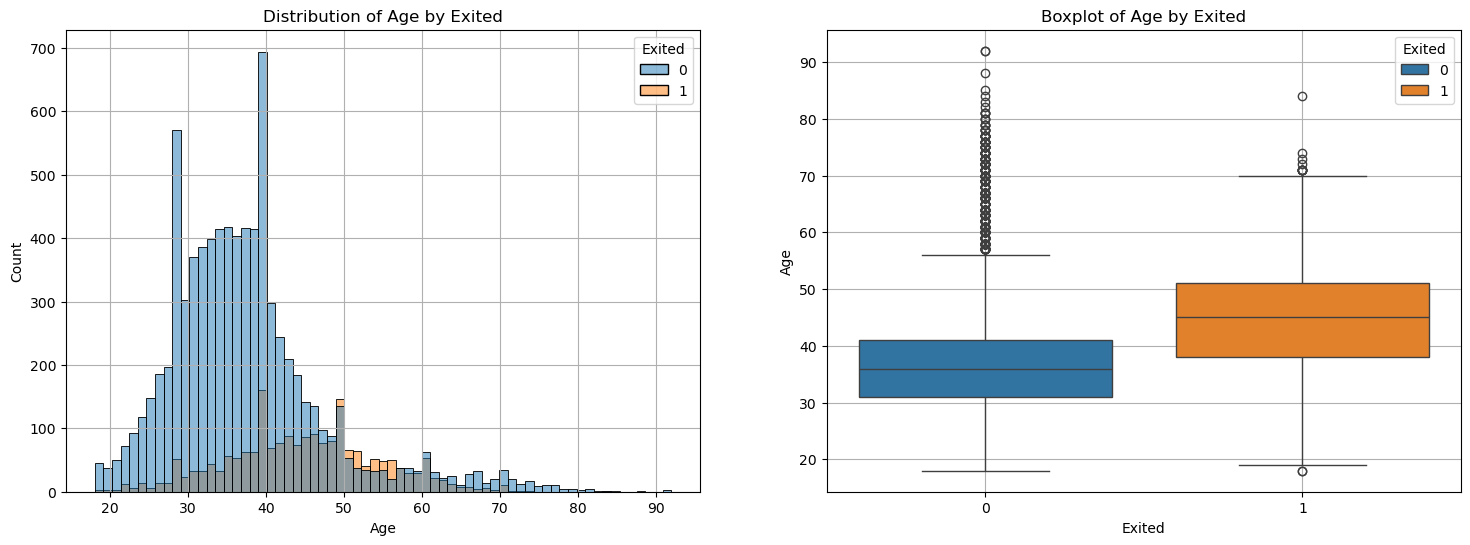

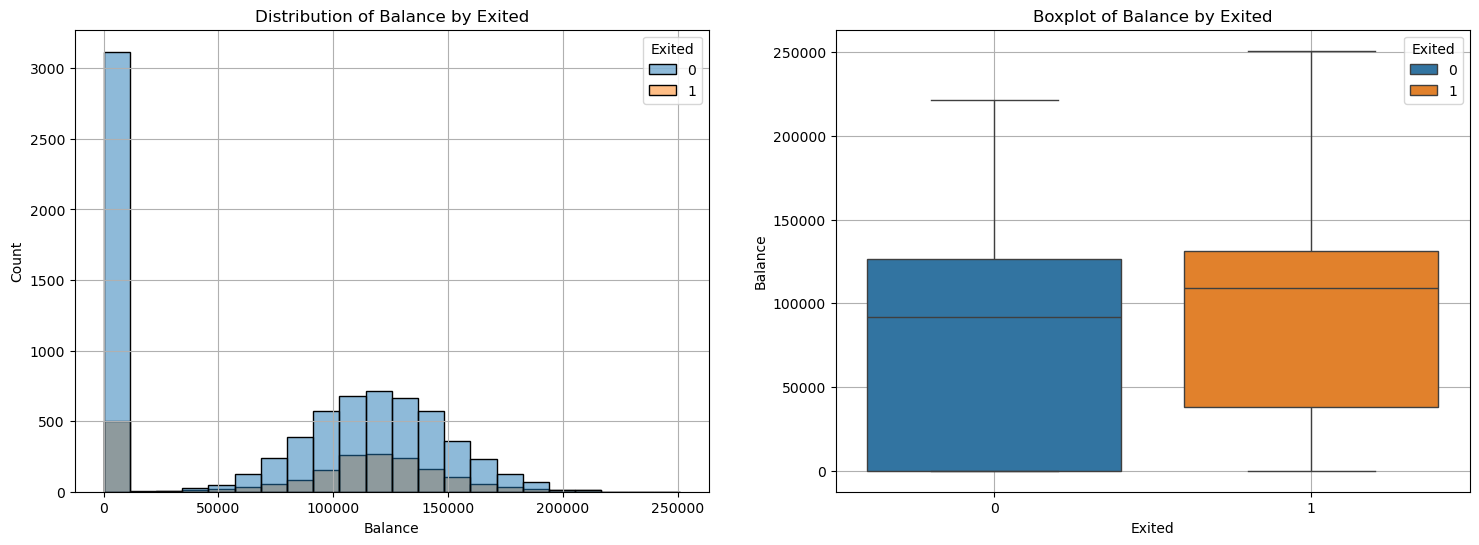

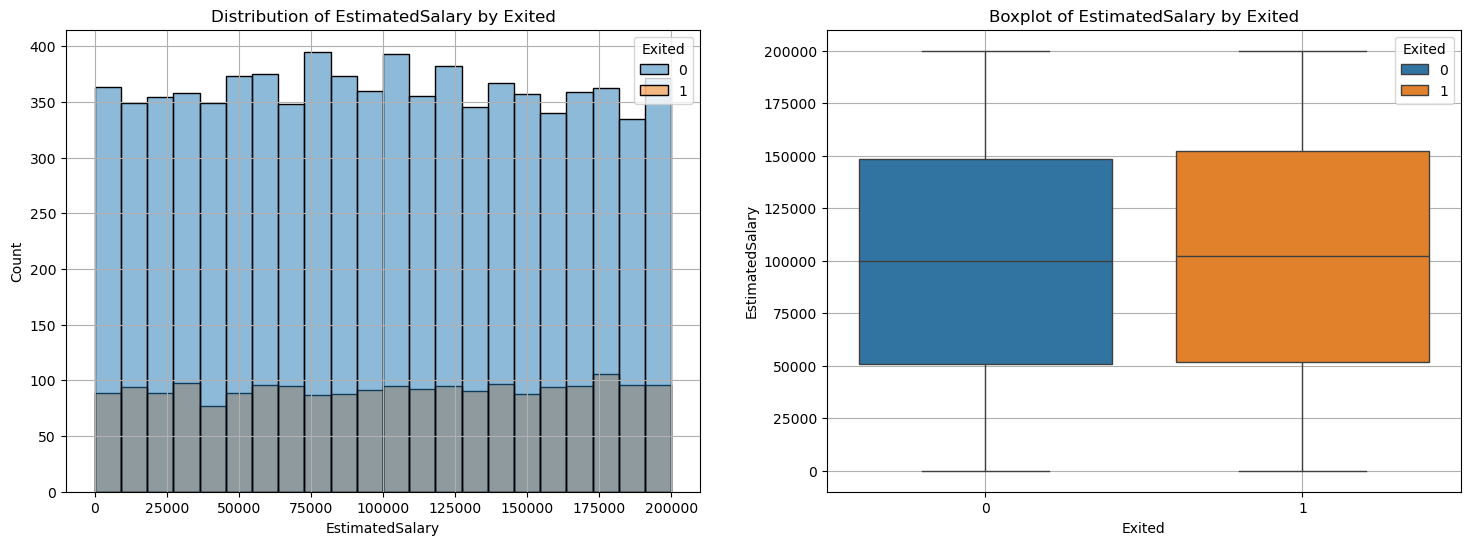

In [31]:
for col in histplot_cols:
    histplot(col)

In [32]:
df[histplot_cols].skew()

CreditScore       -0.071607
Age                1.011320
Balance           -0.141109
EstimatedSalary    0.002085
dtype: float64

## Xulosalar:
- NaN qiymatlar mavjud emas.
- Age utuni o'ng tarafga og'gan log tranformation qo'llaymiz
- CreditScore, Balance va EstimatedSalary ustunlarini scale qilishimiz kerak